In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = pd.read_csv(r"../Dataset/travel_data.csv", parse_dates = ['Travel_Date', 'Booking_Date', 'Booking_Timestamp'])

print(f"Shape of dataset: {data.shape}\n")

data.head()


Shape of dataset: (519713, 25)



,Booking_ID,Customer_ID,Route_ID,Travel_Date,Booking_Date,Booking_Timestamp,Ticket_Price_GBP,Seat_Class,Booking_Channel,Origin,Destination,Distance_km,Route_Category,Customer_Segment,Loyalty_Status,Booking_Frequency_Qtr,Average_Spend_GBP,Total_Seats,Seats_Sold_Realized,Remaining_Seats_Realized,Demand_Index,Base_Price_At_Booking,Days_Before_Travel,Price_Premium,Load_Factor
0,B000000087,C000971,R0001,2025-01-01,2024-11-03,2024-11-03 02:38:21,51.81,Standard,Web,Aberdeen,Leeds,264,Medium,Leisure,NaN,2,17.61,283,167,116,0.798,NaN,58,NaN,0.590106
1,B000000012,C004636,R0001,2025-01-01,2024-11-10,2024-11-10 21:51:11,53.74,Standard,Web,Aberdeen,Leeds,264,Medium,Leisure,Gold,2,41.66,283,167,116,0.798,NaN,51,NaN,0.590106
2,B000000021,C004403,R0001,2025-01-01,2024-11-15,2024-11-15 23:24:12,69.01,Flex,Web,Aberdeen,Leeds,264,Medium,Leisure,NaN,2,39.07,283,167,116,0.798,NaN,46,NaN,0.590106
3,B000000064,C010229,R0001,2025-01-01,2024-11-18,2024-11-18 00:18:54,98.86,First,Mobile,Aberdeen,Leeds,264,Medium,Leisure,NaN,4,45.29,283,167,116,0.798,NaN,43,NaN,0.590106
4,B000000077,C009319,R0001,2025-01-01,2024-11-18,2024-11-18 15:02:18,56.89,Standard,Mobile,Aberdeen,Leeds,264,Medium,Leisure,NaN,4,50.49,283,167,116,0.798,NaN,43,NaN,0.590106


In [ ]:
for column in data:
    if data[column].isnull().any():
        print(column)

Loyalty_Status
Base_Price_At_Booking
Price_Premium


## Data Inspection and Understanding

In [33]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 519713 entries, 0 to 519712
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Booking_ID                519713 non-null  str           
 1   Customer_ID               519713 non-null  str           
 2   Route_ID                  519713 non-null  str           
 3   Travel_Date               519713 non-null  datetime64[us]
 4   Booking_Date              519713 non-null  datetime64[us]
 5   Booking_Timestamp         519713 non-null  datetime64[us]
 6   Ticket_Price_GBP          519713 non-null  float64       
 7   Seat_Class                519713 non-null  str           
 8   Booking_Channel           519713 non-null  str           
 9   Origin                    519713 non-null  str           
 10  Destination               519713 non-null  str           
 11  Distance_km               519713 non-null  int64         
 12  Route_Categor

In [5]:
data.dtypes

Booking_ID                             str
Customer_ID                            str
Route_ID                               str
Travel_Date                 datetime64[us]
Booking_Date                datetime64[us]
Booking_Timestamp           datetime64[us]
Ticket_Price_GBP                   float64
Seat_Class                             str
Booking_Channel                        str
Origin                                 str
Destination                            str
Distance_km                          int64
Route_Category                         str
Customer_Segment                       str
Loyalty_Status                         str
Booking_Frequency_Qtr                int64
Average_Spend_GBP                  float64
Total_Seats                          int64
Seats_Sold_Realized                  int64
Remaining_Seats_Realized             int64
Demand_Index                       float64
Base_Price_At_Booking              float64
Days_Before_Travel                   int64
Price_Premi

In [6]:
data.describe(include=['int', 'float'])

,Ticket_Price_GBP,Distance_km,Booking_Frequency_Qtr,Average_Spend_GBP,Total_Seats,Seats_Sold_Realized,Remaining_Seats_Realized,Demand_Index,Base_Price_At_Booking,Days_Before_Travel,Price_Premium,Load_Factor
count,519713.000000,519713.000000,519713.000000,519713.000000,519713.000000,519713.000000,519713.000000,519713.000000,461445.000000,519713.000000,461445.000000,519713.000000
mean,59.949484,203.925224,5.122545,41.592756,308.997237,254.470173,54.527064,1.070136,52.871776,7.849571,5.394408,0.823364
std,30.365550,86.959412,2.776248,17.236907,71.364323,74.822934,45.034976,0.176269,24.313223,10.580809,11.720304,0.137679
min,12.290000,47.000000,0.000000,10.000000,140.000000,81.000000,3.000000,0.658000,13.360000,0.000000,-14.220000,0.332308
25%,39.800000,169.000000,3.000000,29.780000,258.000000,194.000000,11.000000,0.940000,36.970000,0.000000,-0.310000,0.723810
50%,54.150000,198.000000,5.000000,38.880000,319.000000,248.000000,47.000000,1.055000,49.060000,4.000000,1.060000,0.839161
75%,73.670000,264.000000,7.000000,50.060000,365.000000,315.000000,84.000000,1.190000,64.820000,11.000000,6.490000,0.961686
max,372.860000,362.000000,18.000000,125.520000,420.000000,412.000000,235.000000,1.520000,186.110000,89.000000,191.110000,0.982857


In [7]:
data.describe(include=['object'])


,Booking_ID,Customer_ID,Route_ID,Seat_Class,Booking_Channel,Origin,Destination,Route_Category,Customer_Segment,Loyalty_Status
count,519713,519713,519713,519713,519713,519713,519713,519713,519713,228746
unique,519713,12000,25,3,4,19,15,3,4,3
top,B000000087,C010872,R0003,Standard,Mobile,Sheffield,London,Medium,Commuter,Silver
freq,1,205,31635,374168,233505,61608,62920,362812,221621,131981


In [34]:
data.isnull().sum()

Booking_ID                       0
Customer_ID                      0
Route_ID                         0
Travel_Date                      0
Booking_Date                     0
Booking_Timestamp                0
Ticket_Price_GBP                 0
Seat_Class                       0
Booking_Channel                  0
Origin                           0
Destination                      0
Distance_km                      0
Route_Category                   0
Customer_Segment                 0
Loyalty_Status              290967
Booking_Frequency_Qtr            0
Average_Spend_GBP                0
Total_Seats                      0
Seats_Sold_Realized              0
Remaining_Seats_Realized         0
Demand_Index                     0
Base_Price_At_Booking        58268
Days_Before_Travel               0
Price_Premium                58268
Load_Factor                      0
dtype: int64

In [35]:
data.duplicated().sum()

np.int64(0)

## Data Cleaning

In [10]:
# learning the correlation between null values in Base price and Price premium

data[data['Base_Price_At_Booking'].isnull()][['Base_Price_At_Booking', 'Price_Premium']]

,Base_Price_At_Booking,Price_Premium
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
519586,NaN,NaN
519587,NaN,NaN
519588,NaN,NaN
519589,NaN,NaN


In [11]:
# learning the relationship between null values in Base price and Price premium contd to understand how to handle their null values

data[data['Customer_Segment'] == 'Business'][['Base_Price_At_Booking', 'Price_Premium', 'Ticket_Price_GBP']] 

,Base_Price_At_Booking,Price_Premium,Ticket_Price_GBP
20,59.70,-0.88,58.82
21,59.70,1.13,60.83
23,55.77,0.99,56.76
24,55.77,0.84,56.61
28,55.77,-1.01,54.76
...,...,...,...
519681,48.76,-3.90,44.86
519684,48.76,15.28,64.04
519686,48.76,14.50,63.26
519687,48.76,-0.01,48.75


##### Base_Price_At_Booking + Price_Premium = Ticket_Price_GBP

In [36]:
# Filling in missing data for Base_Price_At_Booking and Price_Premium ensuring the equation above is consistent
mask = data['Base_Price_At_Booking'].isna()

data.loc[mask, 'Base_Price_At_Booking'] = data.loc[mask, 'Ticket_Price_GBP']
data.loc[mask, 'Price_Premium'] = 0

# checking if the equation remains consistent 
check = (
    data['Base_Price_At_Booking'] +
    data['Price_Premium']
) - data['Ticket_Price_GBP']

print(check.abs().max().round(3))


0.0


In [37]:
data['Loyalty_Status'] = data['Loyalty_Status'].fillna('Not loyal')

In [38]:
data.isnull().sum()

Booking_ID                  0
Customer_ID                 0
Route_ID                    0
Travel_Date                 0
Booking_Date                0
Booking_Timestamp           0
Ticket_Price_GBP            0
Seat_Class                  0
Booking_Channel             0
Origin                      0
Destination                 0
Distance_km                 0
Route_Category              0
Customer_Segment            0
Loyalty_Status              0
Booking_Frequency_Qtr       0
Average_Spend_GBP           0
Total_Seats                 0
Seats_Sold_Realized         0
Remaining_Seats_Realized    0
Demand_Index                0
Base_Price_At_Booking       0
Days_Before_Travel          0
Price_Premium               0
Load_Factor                 0
dtype: int64

In [39]:
data.columns = data.columns.str.lower()

In [40]:
categorical_cols = ['seat_class', 'booking_channel', 'origin', 'destination', 'route_category', 'customer_segment', 'loyalty_status']

for col in categorical_cols:
    print(f'{data[col].value_counts()}\n')

seat_class
Standard    374168
Flex        114228
First        31317
Name: count, dtype: int64

booking_channel
Mobile     233505
Web        187437
Agent       62577
Partner     36194
Name: count, dtype: int64

origin
Sheffield        61608
Bristol          47820
York             37746
Southampton      32504
Birmingham       31635
Manchester       30712
Exeter           29310
Cardiff          28288
Leeds            26398
Liverpool        26026
Leicester        24581
Aberdeen         20635
London           20246
Edinburgh        19579
Brighton         19483
Reading          17322
Belfast          17180
Milton Keynes    14510
Coventry         14130
Name: count, dtype: int64

destination
London         62920
Leeds          55137
Birmingham     51483
Nottingham     46241
Liverpool      44296
Glasgow        36449
Bristol        36124
Aberdeen       34756
Oxford         31066
Coventry       28288
Southampton    24581
Exeter         19579
Leicester      19483
Reading        15113
York         

In [41]:
data.head()

,booking_id,customer_id,route_id,travel_date,booking_date,booking_timestamp,ticket_price_gbp,seat_class,booking_channel,origin,destination,distance_km,route_category,customer_segment,loyalty_status,booking_frequency_qtr,average_spend_gbp,total_seats,seats_sold_realized,remaining_seats_realized,demand_index,base_price_at_booking,days_before_travel,price_premium,load_factor
0,B000000087,C000971,R0001,2025-01-01,2024-11-03,2024-11-03 02:38:21,51.81,Standard,Web,Aberdeen,Leeds,264,Medium,Leisure,Not loyal,2,17.61,283,167,116,0.798,51.81,58,0.0,0.590106
1,B000000012,C004636,R0001,2025-01-01,2024-11-10,2024-11-10 21:51:11,53.74,Standard,Web,Aberdeen,Leeds,264,Medium,Leisure,Gold,2,41.66,283,167,116,0.798,53.74,51,0.0,0.590106
2,B000000021,C004403,R0001,2025-01-01,2024-11-15,2024-11-15 23:24:12,69.01,Flex,Web,Aberdeen,Leeds,264,Medium,Leisure,Not loyal,2,39.07,283,167,116,0.798,69.01,46,0.0,0.590106
3,B000000064,C010229,R0001,2025-01-01,2024-11-18,2024-11-18 00:18:54,98.86,First,Mobile,Aberdeen,Leeds,264,Medium,Leisure,Not loyal,4,45.29,283,167,116,0.798,98.86,43,0.0,0.590106
4,B000000077,C009319,R0001,2025-01-01,2024-11-18,2024-11-18 15:02:18,56.89,Standard,Mobile,Aberdeen,Leeds,264,Medium,Leisure,Not loyal,4,50.49,283,167,116,0.798,56.89,43,0.0,0.590106


## Exploratory Data Analysis

In [18]:
data.columns

Index(['booking_id', 'customer_id', 'route_id', 'travel_date', 'booking_date',
       'booking_timestamp', 'ticket_price_gbp', 'seat_class',
       'booking_channel', 'origin', 'destination', 'distance_km',
       'route_category', 'customer_segment', 'loyalty_status',
       'booking_frequency_qtr', 'average_spend_gbp', 'total_seats',
       'seats_sold_realized', 'remaining_seats_realized', 'demand_index',
       'base_price_at_booking', 'days_before_travel', 'price_premium',
       'load_factor'],
      dtype='str')

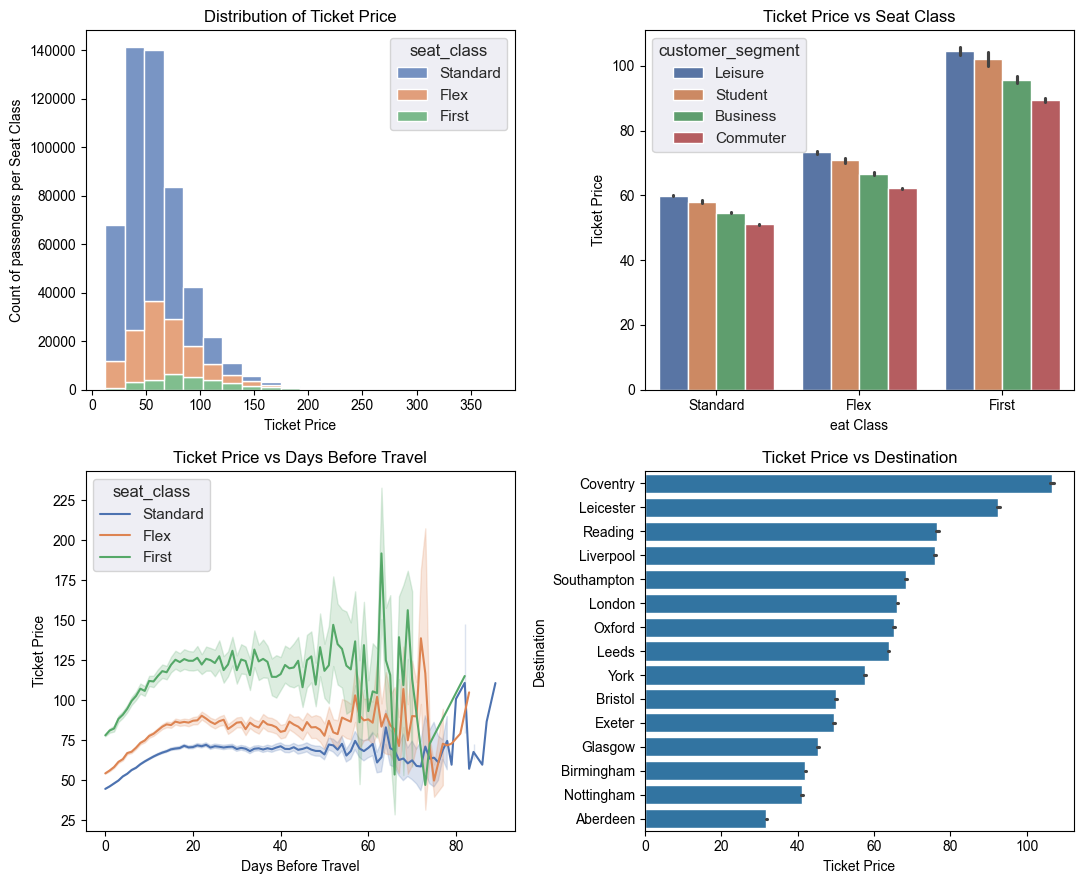

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
sns.set_theme()

sns.histplot(data=data, x='ticket_price_gbp', hue='seat_class', multiple='stack', bins=20, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Ticket Price')
axes[0, 0].set_xlabel('Ticket Price')
axes[0, 0].set_ylabel('Count of passengers per Seat Class')

sns.barplot(data=data, x='seat_class', y='ticket_price_gbp', hue='customer_segment', ax=axes[0, 1])
axes[0, 1].set_title('Ticket Price vs Seat Class')
axes[0, 1].set_xlabel('eat Class')
axes[0, 1].set_ylabel('Ticket Price')

sns.lineplot(data=data, x='days_before_travel', y='ticket_price_gbp', hue='seat_class', ax=axes[1, 0])
axes[1, 0].set_title('Ticket Price vs Days Before Travel')
axes[1, 0].set_xlabel('Days Before Travel')
axes[1, 0].set_ylabel('Ticket Price')

order_list_destination = data.groupby('destination')['ticket_price_gbp'].mean().sort_values(ascending=False).index
sns.barplot(data=data, x='ticket_price_gbp', y='destination', order=order_list_destination, ax=axes[1, 1])
axes[1, 1].set_title('Ticket Price vs Destination')
axes[1, 1].set_xlabel('Ticket Price')
axes[1, 1].set_ylabel('Destination')

plt.tight_layout()
plt.show()

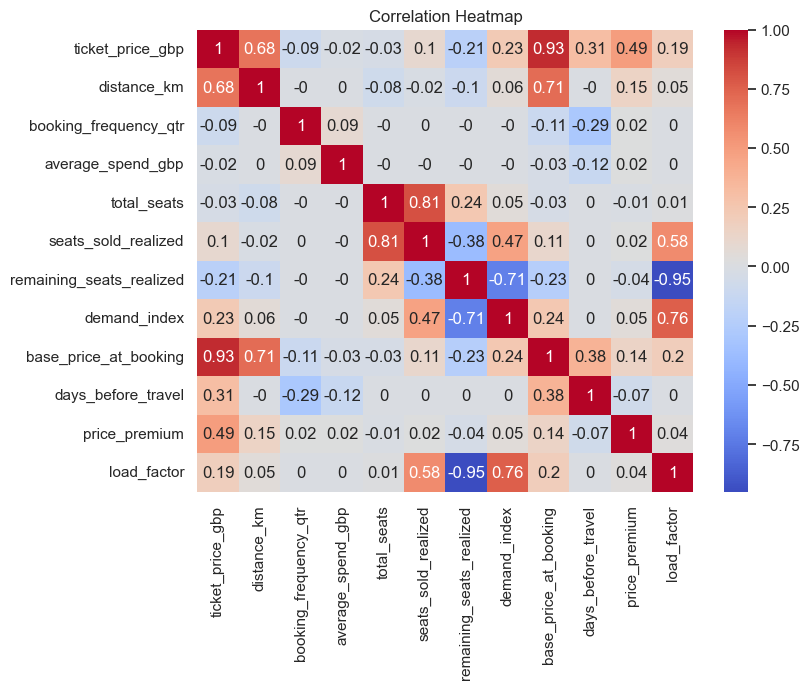

In [22]:
plt.figure(figsize=(8, 6))
numerical_column = data.select_dtypes(include=['float', 'int'])
corr = numerical_column.corr().round(2)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Feature Engineering

In [23]:
data.head()

,booking_id,customer_id,route_id,travel_date,booking_date,booking_timestamp,ticket_price_gbp,seat_class,booking_channel,origin,destination,distance_km,route_category,customer_segment,loyalty_status,booking_frequency_qtr,average_spend_gbp,total_seats,seats_sold_realized,remaining_seats_realized,demand_index,base_price_at_booking,days_before_travel,price_premium,load_factor
0,B000000087,C000971,R0001,2025-01-01,2024-11-03,2024-11-03 02:38:21,51.81,Standard,Web,Aberdeen,Leeds,264,Medium,Leisure,Not loyal,2,17.61,283,167,116,0.798,51.81,58,0.0,0.590106
1,B000000012,C004636,R0001,2025-01-01,2024-11-10,2024-11-10 21:51:11,53.74,Standard,Web,Aberdeen,Leeds,264,Medium,Leisure,Gold,2,41.66,283,167,116,0.798,53.74,51,0.0,0.590106
2,B000000021,C004403,R0001,2025-01-01,2024-11-15,2024-11-15 23:24:12,69.01,Flex,Web,Aberdeen,Leeds,264,Medium,Leisure,Not loyal,2,39.07,283,167,116,0.798,69.01,46,0.0,0.590106
3,B000000064,C010229,R0001,2025-01-01,2024-11-18,2024-11-18 00:18:54,98.86,First,Mobile,Aberdeen,Leeds,264,Medium,Leisure,Not loyal,4,45.29,283,167,116,0.798,98.86,43,0.0,0.590106
4,B000000077,C009319,R0001,2025-01-01,2024-11-18,2024-11-18 15:02:18,56.89,Standard,Mobile,Aberdeen,Leeds,264,Medium,Leisure,Not loyal,4,50.49,283,167,116,0.798,56.89,43,0.0,0.590106


### Engineering Time-Based Features

In [42]:
data['booking_month'] = data['booking_date'].dt.month
data['booking_day_of_week'] = data['booking_date'].dt.dayofweek
data['travel_month'] = data['travel_date'].dt.month
data['travel_day_of_week'] = data['travel_date'].dt.dayofweek
data['is_weekend_travel'] = data['travel_day_of_week'].isin([4,5,6]).astype(int)

data = data.drop(columns= ['booking_date', 'travel_date', 'booking_timestamp'])

### Engineering Customer-strength Features

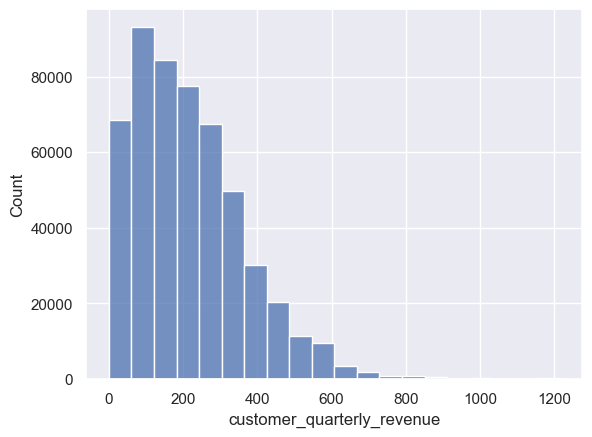

In [43]:
data['customer_quarterly_revenue'] = data['booking_frequency_qtr'] * data['average_spend_gbp']

sns.histplot(data=data, x='customer_quarterly_revenue', bins=20)

data = data.drop(columns= ['booking_frequency_qtr', 'average_spend_gbp'])

### Engineering Scarcity Features

<Axes: xlabel='scarcity_index', ylabel='Count'>

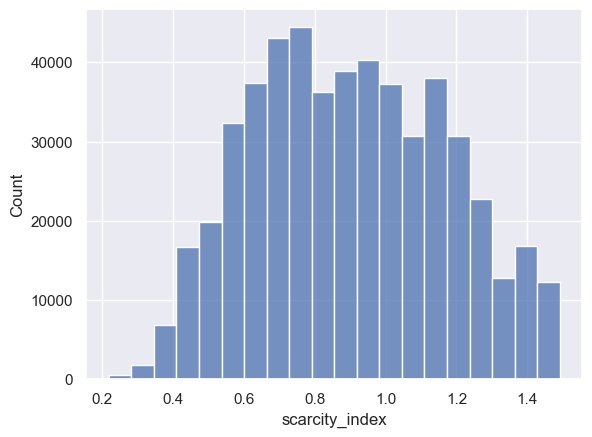

In [44]:

# Seat utilization
data['seat_utilization_ratio'] = (data['seats_sold_realized'] / data['total_seats'].replace(0, np.nan))

# Scarcity index
data['scarcity_index'] = (data['demand_index'] * data['seat_utilization_ratio'])

data = data.drop(columns= ['seat_utilization_ratio', 'seats_sold_realized', 'total_seats', 'demand_index'])

sns.histplot(data=data, x='scarcity_index', bins=20)

Text(0.5, 1.0, 'Correlation Heatmap')

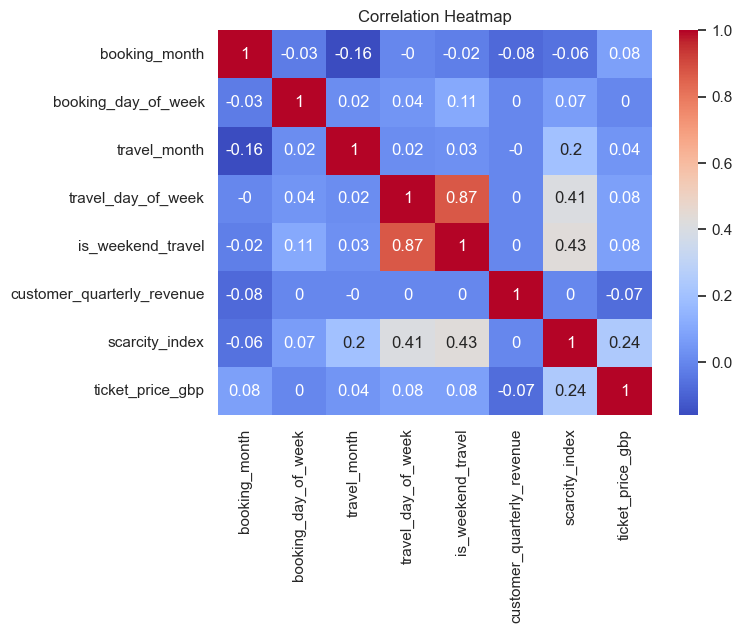

In [45]:
engineered_features = ['booking_month', 'booking_day_of_week', 'travel_month', 'travel_day_of_week', 'is_weekend_travel', 'customer_quarterly_revenue',\
                       'scarcity_index']

engineered_vs_target = [*engineered_features, 'ticket_price_gbp']

engineered_vs_target_df = data[engineered_vs_target]

engineered_vs_target_corr = engineered_vs_target_df.corr().round(2)
plt.figure(figsize=(7, 5))
sns.heatmap(data=engineered_vs_target_corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

In [46]:
# dropping unrequired columns

data = data.drop(columns=['travel_day_of_week', 'base_price_at_booking', 'price_premium', 'load_factor', 'booking_day_of_week'])
data.head()

,booking_id,customer_id,route_id,ticket_price_gbp,seat_class,booking_channel,origin,destination,distance_km,route_category,customer_segment,loyalty_status,remaining_seats_realized,days_before_travel,booking_month,travel_month,is_weekend_travel,customer_quarterly_revenue,scarcity_index
0,B000000087,C000971,R0001,51.81,Standard,Web,Aberdeen,Leeds,264,Medium,Leisure,Not loyal,116,58,11,1,0,35.22,0.470905
1,B000000012,C004636,R0001,53.74,Standard,Web,Aberdeen,Leeds,264,Medium,Leisure,Gold,116,51,11,1,0,83.32,0.470905
2,B000000021,C004403,R0001,69.01,Flex,Web,Aberdeen,Leeds,264,Medium,Leisure,Not loyal,116,46,11,1,0,78.14,0.470905
3,B000000064,C010229,R0001,98.86,First,Mobile,Aberdeen,Leeds,264,Medium,Leisure,Not loyal,116,43,11,1,0,181.16,0.470905
4,B000000077,C009319,R0001,56.89,Standard,Mobile,Aberdeen,Leeds,264,Medium,Leisure,Not loyal,116,43,11,1,0,201.96,0.470905


In [48]:
# saving processed dataset

from operator import index


data.to_csv(r'../Dataset/processed_travel_data.csv', index=False)